<a href="https://colab.research.google.com/github/Laljanbasha111/Laljanbasha111/blob/main/tuberculosis_b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
uploaded = files.upload()

In [13]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

In [14]:
import os
os.listdir()

['.config', 'archive (3).zip', 'sample_data']

In [15]:
!ls

'archive (3).zip'   sample_data


In [16]:
import zipfile
import os

zip_file_name = 'archive(3).zip'
if os.path.exists(zip_file_name):
    with zipfile.ZipFile(zip_file_name, 'r') as zip_ref:
        zip_ref.extractall('dataset')
    print(f"Successfully extracted {zip_file_name} to 'dataset'.")
else:
    print(f"Error: The file '{zip_file_name}' was not found.")
    print("Please ensure you have uploaded 'archive.zip' to the current directory.")
    print("You can use `from google.colab import files; files.upload()` to upload it.")
    print("Then, verify its presence using `!ls` or `os.listdir()`.")

Error: The file 'archive(3).zip' was not found.
Please ensure you have uploaded 'archive.zip' to the current directory.
You can use `from google.colab import files; files.upload()` to upload it.
Then, verify its presence using `!ls` or `os.listdir()`.


In [17]:
!unzip -o "archive (3).zip"

Archive:  archive (3).zip
  inflating: TB_Chest_Radiography_Database/Normal.metadata.xlsx  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-10.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-100.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1000.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1001.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1002.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1003.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1004.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1005.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1006.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1007.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1008.png  
  inflating: TB_Chest_Radiography_Database/Normal/Normal-1009.png  
  inflating: TB_Chest_Radiogra

In [18]:
!ls

'archive (3).zip'   sample_data   TB_Chest_Radiography_Database


In [19]:
!ls TB_Chest_Radiography_Database

Normal		      README.md.txt  Tuberculosis.metadata.xlsx
Normal.metadata.xlsx  Tuberculosis


In [20]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "TB_Chest_Radiography_Database",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "TB_Chest_Radiography_Database",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 4200 files belonging to 2 classes.
Using 3360 files for training.
Found 4200 files belonging to 2 classes.
Using 840 files for validation.


In [21]:
train_data = train_data.map(lambda x, y: (x/255.0, y))
val_data = val_data.map(lambda x, y: (x/255.0, y))

In [22]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [23]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [24]:
model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 71s 374ms/step - accuracy: 0.7946 - loss: 0.5924 - val_accuracy: 0.8250 - val_loss: 0.5568
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 221ms/step - accuracy: 0.8039 - loss: 0.5580 - val_accuracy: 0.8250 - val_loss: 0.5763
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.8250 - loss: 0.5022 - val_accuracy: 0.8250 - val_loss: 0.6214
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.8295 - loss: 0.4911 - val_accuracy: 0.8250 - val_loss: 0.6246
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.8327 - loss: 0.4736 - val_accuracy: 0.8250 - val_loss: 0.6145
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 266ms/step - accuracy: 0.8342 - loss: 0.4671 - val_accuracy: 0.8250 - val_loss: 0.5741
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.8318 - loss: 0.4597 - val_accuracy: 0.8250 - val_loss: 0.5608
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.8360 - loss: 0

In [25]:
import os

normal_count = len(os.listdir("TB_Chest_Radiography_Database/Normal"))
tb_count = len(os.listdir("TB_Chest_Radiography_Database/Tuberculosis"))

print("Normal:", normal_count)
print("TB:", tb_count)

Normal: 3500
TB: 700


In [26]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = []

for _, y in train_data.unbatch():
    labels.append(y.numpy())

labels = np.array(labels)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.5985037406483791), 1: np.float64(3.037974683544304)}


In [27]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    class_weight=class_weights
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 40s 206ms/step - accuracy: 0.6030 - loss: 0.7530 - val_accuracy: 0.8250 - val_loss: 0.6461
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step - accuracy: 0.5685 - loss: 0.7023 - val_accuracy: 0.8250 - val_loss: 0.6589
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 222ms/step - accuracy: 0.5699 - loss: 0.6970 - val_accuracy: 0.8250 - val_loss: 0.6441
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.5976 - loss: 0.6915 - val_accuracy: 0.8250 - val_loss: 0.6471
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 207ms/step - accuracy: 0.5780 - loss: 0.6879 - val_accuracy: 0.8250 - val_loss: 0.6518
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step - accuracy: 0.5988 - loss: 0.6948 - val_accuracy: 0.8250 - val_loss: 0.6633
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 220ms/step - accuracy: 0.5979 - loss: 0.6860 - val_accuracy: 0.8250 - val_loss: 0.6604
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.6229 - loss: 0

In [28]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = []
y_pred = []

for x, y in val_data:
    preds = model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)
print(cm)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 157ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 220ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Precision(),
        tf.keras.metrics.Recall()
    ]
)

In [ ]:
model.evaluate(val_data)

27/27 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.8250 - loss: 0.6461 - precision: 0.0000e+00 - recall: 0.0000e+00


[0.646091878414154, 0.824999988079071, 0.0, 0.0]

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

y_true = []
y_pred = []

for x, y in val_data:
    preds = model.predict(x)
    y_true.extend(y.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 163ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 159ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
from google.colab import files
files.upload()

Saving Tuberculosis-9.png to Tuberculosis-9.png


{'Tuberculosis-9.png': b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x02\x00\x00\x00\x02\x00\x08\x00\x00\x00\x00\xd1\x13\x8b&\x00\x00\x00\x07tIME\x07\xe5\x03\x07\x15\x11\x02\xf7\x10A_\x00\x00 \x00IDATx\x9c\xec\xbd\xd9\x96\xe4H\xb2\x1c(\xa2\x06\x8f\xec\x1a\xce\xff\x7f)\xe72\xc3\x1d\xa62\x0f\xba\x98\x01\xee\x99\x95u\xc99\xbcg\xd8\xa8\xee\x8c\x08_\x00[t\x11]\r\xf8\xf7\xf5\xef\xeb\xdf\xd7\xbf\xaf\x7f_\xff\x87^\xfc\xdf=\x80\xff\xef/\x02\xd0\xed\xef\x7fv\t\xbc\xdc\xe1\xffO\xd7\x7f!\x02\xf8\xa7C\xf9\xd3\xcf\xff\xef!\x80?\xf9\xfc\x7f\x05\xa2:\xfew\x0f\xe0O\xaf?]\xac\xf7\xcf\xed\x04p\'\x86\xdf\xdf\x85\xdb\xf7\xfe+l\xd6\xff\xca\x8b=\xc7\x7f_\xff\x07^\x04\xe1\xf9\xdb\x7f\xa1k\xa7J\xf5\xcf\xf5/H\xaew>\xde\x81|{\xcb\xa0\x9d\x7f\xfb#\xbf\xe4\xea\xed&\xe4\xd0\xf4\xf5VK\x04\xbb~[\xef\xbf\x91\xd4\xf6\x8a.\xef+G\x16\xbf\xabG\xa8\xed\x13\xcaO\xa8\xff\x02\x1c\xea\x7f\xff\xf9\xb5-\r\rr\xe1\xbf\x94\n\xa0\xdd\xf7\x8e72\xb0\xf1\xb0O\x82\xab6\x94\xc0\xf1\xe3\xd8\xbf-\xd0\x0e\xca\xcf\\1A\xc7\xbf\x8e\xd8c\xf6\xd

In [ ]:
model.save("tb_detection_model.h5")

In [ ]:
model.save("tb_detection_model.keras")

In [ ]:
from google.colab import files
files.download("tb_model.keras")

FileNotFoundError: Cannot find file: tb_model.keras

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Model Accuracy')
plt.show()

NameError: name 'history' is not defined

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 46s 209ms/step - accuracy: 0.7357 - loss: 0.6146 - precision: 0.2519 - recall: 0.3074 - val_accuracy: 0.8250 - val_loss: 0.6449 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 205ms/step - accuracy: 0.7676 - loss: 0.5841 - precision: 0.2047 - recall: 0.1429 - val_accuracy: 0.8250 - val_loss: 0.6397 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 213ms/step - accuracy: 0.8036 - loss: 0.5540 - precision: 0.2365 - recall: 0.0868 - val_accuracy: 0.8250 - val_loss: 0.6342 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 216ms/step - accuracy: 0.8190 - loss: 0.5381 - precision: 0.2277 - recall: 0.0416 - val_accuracy: 0.8250 - val_loss: 0.6299 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 213ms/step - accuracy: 0.8280 - loss: 0.5238 - precision: 0.3134 - recal

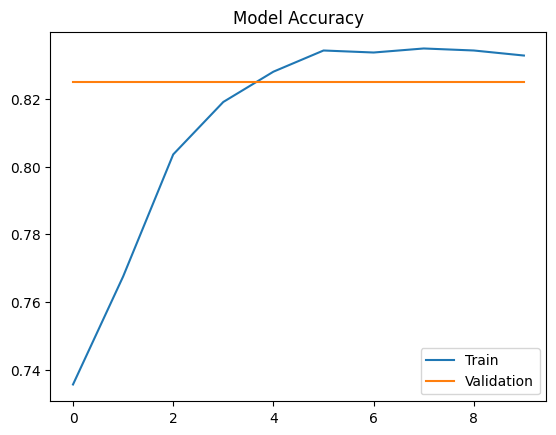

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Model Accuracy')
plt.show()

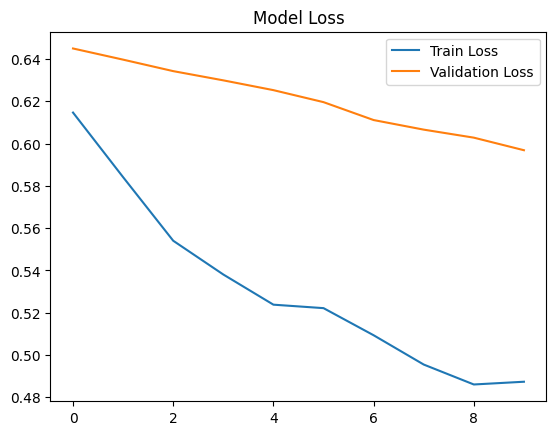

In [ ]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train Loss', 'Validation Loss'])
plt.title('Model Loss')
plt.show()

In [ ]:
from google.colab import files
files.download("tb_detection_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=25
)

NameError: name 'model' is not defined

In [29]:
!ls

'archive (3).zip'   sample_data   TB_Chest_Radiography_Database


In [30]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "TB_Chest_Radiography_Database",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "TB_Chest_Radiography_Database",
    image_size=(224, 224),
    batch_size=32,
    validation_split=0.2,
    subset="validation",
    seed=123
)

Found 4200 files belonging to 2 classes.
Using 3360 files for training.
Found 4200 files belonging to 2 classes.
Using 840 files for validation.


In [31]:
train_data = train_data.map(lambda x, y: (x/255.0, y))
val_data = val_data.map(lambda x, y: (x/255.0, y))

In [32]:
from tensorflow.keras import layers, models

base_model = tf.keras.applications.EfficientNetB0(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

In [33]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [34]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 115s 328ms/step - accuracy: 0.7509 - loss: 0.5080 - val_accuracy: 0.1750 - val_loss: 1.0417
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 234ms/step - accuracy: 0.8494 - loss: 0.3468 - val_accuracy: 0.1750 - val_loss: 0.7639
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 218ms/step - accuracy: 0.9039 - loss: 0.2520 - val_accuracy: 0.1917 - val_loss: 0.9711
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9229 - loss: 0.2132 - val_accuracy: 0.2250 - val_loss: 1.1640
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step - accuracy: 0.9378 - loss: 0.1821 - val_accuracy: 0.1952 - val_loss: 1.6842
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 232ms/step - accuracy: 0.9476 - loss: 0.1519 - val_accuracy: 0.1798 - val_loss: 2.0551
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 277ms/step - accuracy: 0.9676 - loss: 0.1215 - val_accuracy: 0.2893 - val_loss: 1.3548
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 234ms/step - accuracy: 0.9643 - loss: 

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early = EarlyStopping(patience=5, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3
)

model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early, reduce_lr]
)

Epoch 1/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 226ms/step - accuracy: 0.8351 - loss: 0.4504 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8250 - val_loss: 0.5424 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 2/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 204ms/step - accuracy: 0.8348 - loss: 0.4428 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8250 - val_loss: 0.5457 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 3/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 23s 219ms/step - accuracy: 0.8348 - loss: 0.4450 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8250 - val_loss: 0.5479 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-05
Epoch 4/30
105/105 ━━━━━━━━━━━━━━━━━━━━ 22s 212ms/step - accuracy: 0.8354 - loss: 0.4427 - precision: 0.0000e+00 - recall: 0.0000e+00 - val_accuracy: 0.8250 - val_loss: 0.5458 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 

In [ ]:
base_model = tf.keras.applications.EfficientNetB3(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [36]:
import tensorflow as tf
model = tf.keras.models.load_model("tb_detection_model.keras")

ValueError: File not found: filepath=tb_detection_model.keras. Please ensure the file is an accessible `.keras` zip file.

Saving Tuberculosis-80.png to Tuberculosis-80.png


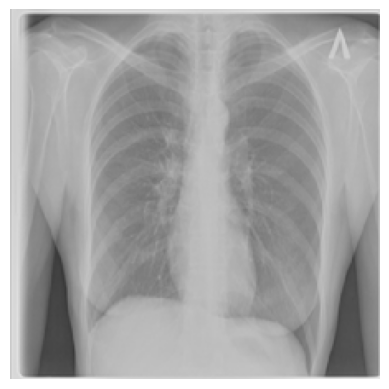

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step
🚨 TB DETECTED (High Confidence: 1.00)


In [37]:
from google.colab import files
uploaded = files.upload()

import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

img_path = list(uploaded.keys())[0]

img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

pred = model.predict(img_array)[0][0]

if pred > 0.6:
    print(f"🚨 TB DETECTED (High Confidence: {pred:.2f})")

elif pred > 0.4:
    print(f"⚠️ POSSIBLE TB (Medium Confidence: {pred:.2f})")

else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

In [ ]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load and display image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("X-ray Input")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# FINAL DECISION SYSTEM 🔥
if pred > 0.6:
    print(f"🚨 TB DETECTED (High Confidence: {pred:.2f})")

elif pred > 0.4:
    print(f"⚠️ POSSIBLE TB (Medium Confidence: {pred:.2f})")

else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

Saving Tuberculosis-699.png to Tuberculosis-699.png


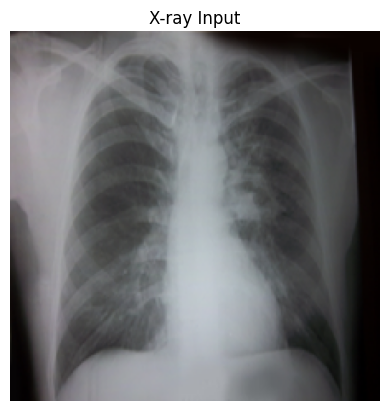

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
🚨 TB DETECTED (High Confidence: 1.00)


In [38]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load and display image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("X-ray Input")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# FINAL DECISION SYSTEM 🔥
if pred > 0.6:
    print(f"🚨 TB DETECTED (High Confidence: {pred:.2f})")

elif pred > 0.4:
    print(f"⚠️ POSSIBLE TB (Medium Confidence: {pred:.2f})")

else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

In [ ]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2)
])

Saving Tuberculosis-496.png to Tuberculosis-496.png


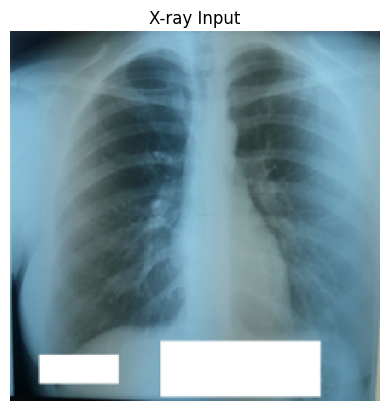

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
🚨 TB DETECTED (High Confidence: 1.00)
📊 Model Accuracy: 17.50%


In [40]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Show image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("X-ray Input")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# 🔥 GET MODEL ACCURACY
loss, acc = model.evaluate(val_data, verbose=0)

# RESULT
if pred > 0.6:
    result = f"🚨 TB DETECTED (High Confidence: {pred:.2f})"
elif pred > 0.4:
    result = f"⚠️ POSSIBLE TB (Confidence: {pred:.2f})"
else:
    result = f"✅ NORMAL (Confidence: {1-pred:.2f})"

print(result)
print(f"📊 Model Accuracy: {acc*100:.2f}%")

In [ ]:
files.download("tb_detection_model.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Saving Normal-989.png to Normal-989.png


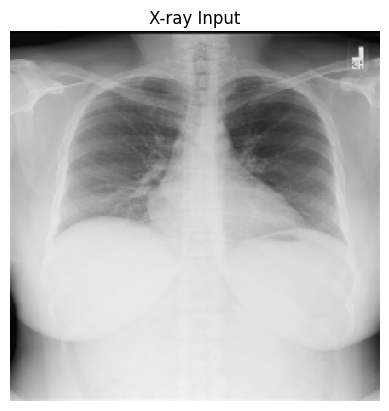

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
🚨 TB DETECTED (High Confidence: 0.95)
📊 Model Accuracy: 17.50%


In [41]:
from google.colab import files
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Upload image
uploaded = files.upload()

img_path = list(uploaded.keys())[0]

# Show image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("X-ray Input")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# 🔥 GET MODEL ACCURACY
loss, acc = model.evaluate(val_data, verbose=0)

# RESULT
if pred > 0.6:
    result = f"🚨 TB DETECTED (High Confidence: {pred:.2f})"
elif pred > 0.4:
    result = f"⚠️ POSSIBLE TB (Confidence: {pred:.2f})"
else:
    result = f"✅ NORMAL (Confidence: {1-pred:.2f})"

print(result)
print(f"📊 Model Accuracy: {acc*100:.2f}%")

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.Recall(),
        tf.keras.metrics.Precision()
    ]
)

In [42]:
if pred > 0.7:
    print(f"🚨 TB DETECTED (High Confidence: {pred:.2f})")

elif pred > 0.5:
    print(f"⚠️ POSSIBLE TB (Medium Confidence: {pred:.2f})")

else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

🚨 TB DETECTED (High Confidence: 0.95)


In [43]:
!ls TB_Chest_Radiography_Database

Normal		      README.md.txt  Tuberculosis.metadata.xlsx
Normal.metadata.xlsx  Tuberculosis


In [44]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = np.concatenate([y for x, y in train_data], axis=0)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)

class_weights = dict(enumerate(class_weights))
print(class_weights)

{0: np.float64(0.5985037406483791), 1: np.float64(3.037974683544304)}


In [45]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=15,
    class_weight=class_weights
)

Epoch 1/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 77s 211ms/step - accuracy: 0.9804 - loss: 0.0814 - val_accuracy: 0.1750 - val_loss: 3.7857
Epoch 2/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 229ms/step - accuracy: 0.9774 - loss: 0.0716 - val_accuracy: 0.3905 - val_loss: 1.3250
Epoch 3/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 25s 238ms/step - accuracy: 0.9786 - loss: 0.0588 - val_accuracy: 0.3131 - val_loss: 1.6579
Epoch 4/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 26s 243ms/step - accuracy: 0.9792 - loss: 0.0608 - val_accuracy: 0.2143 - val_loss: 2.6924
Epoch 5/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 228ms/step - accuracy: 0.9845 - loss: 0.0423 - val_accuracy: 0.6964 - val_loss: 0.6112
Epoch 6/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 229ms/step - accuracy: 0.9872 - loss: 0.0454 - val_accuracy: 0.4167 - val_loss: 1.4197
Epoch 7/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 30s 290ms/step - accuracy: 0.9842 - loss: 0.0437 - val_accuracy: 0.8131 - val_loss: 0.4171
Epoch 8/15
105/105 ━━━━━━━━━━━━━━━━━━━━ 24s 229ms/step - accuracy: 0.9863 - loss: 0

In [ ]:
pred > 0.5

NameError: name 'pred' is not defined

In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image

def predict_tb(img_path):
    img = image.load_img(img_path, target_size=(224,224))
    img = image.img_to_array(img)/255.0
    img = np.expand_dims(img, axis=0)

    pred = model.predict(img)[0][0]

    if pred > 0.4:   # tuned threshold
        return f"TB Detected ({pred:.2f})"
    else:
        return f"Normal ({1-pred:.2f})"

In [ ]:
print(predict_tb("Tuberculosis-8.png"))
print(predict_tb("Tuberculosis-9.png"))

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step
Normal (0.64)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
Normal (0.65)


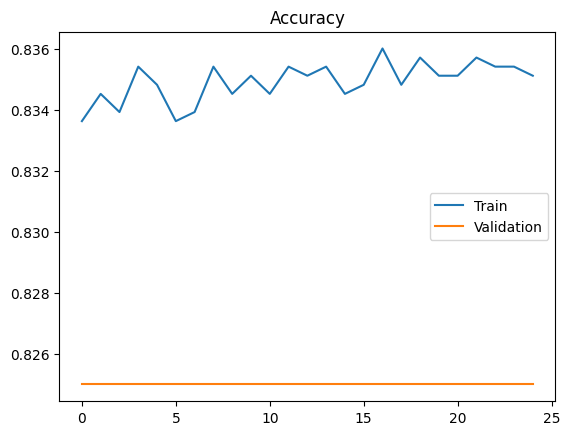

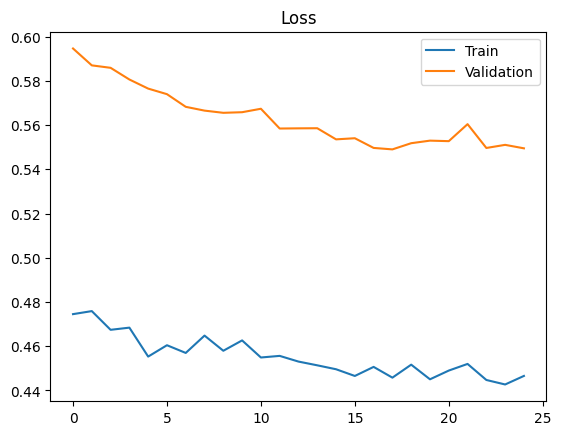

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("Accuracy")
plt.legend(["Train", "Validation"])
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train", "Validation"])
plt.show()

In [ ]:
model.save("tb_final_model.keras")

In [ ]:
from google.colab import files
files.download("tb_final_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
!pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 87.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 92.8 MB/s eta 0:00:00


In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image

model = tf.keras.models.load_model("tb_detection_model.keras")

st.title("TB Detection from X-ray")

uploaded_file = st.file_uploader("Upload X-ray Image", type=["jpg","png"])

if uploaded_file is not None:
    img = Image.open(uploaded_file).resize((224,224))
    st.image(img, caption="Uploaded Image")

    img_array = np.array(img)/255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)[0][0]

    if pred > 0.4:
        st.error(f"TB Detected ({pred:.2f})")
    else:
        st.success(f"Normal ({1-pred:.2f})")

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501

⠙

⠹⠸⠼⠴⠦⠧⠇⠏Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.104.172:8501

  Stopping...
^C


In [ ]:
!ls

'archive (3).zip'		 tb_detection_model.h5	    Tuberculosis-9.png
 sample_data			 tb_detection_model.keras
 TB_Chest_Radiography_Database	 Tuberculosis-8.png


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Tuberculosis-77.png to Tuberculosis-77.png


In [11]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get uploaded file name
img_path = list(uploaded.keys())[0]

# Show image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("Input X-ray")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# Result
if pred > 0.4:
    print(f"⚠️ TB DETECTED (Confidence: {pred:.2f})")
else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

NameError: name 'uploaded' is not defined

In [ ]:
import tensorflow as tf

model = tf.keras.models.load_model("tb_detection_model.keras")

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 8 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
pred = model.predict(img_array)[0][0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


In [ ]:
# 1. Load model
model = tf.keras.models.load_model("tb_detection_model.keras")

# 2. Upload image
from google.colab import files
uploaded = files.upload()

# 3. Predict

Saving Tuberculosis-78.png to Tuberculosis-78.png


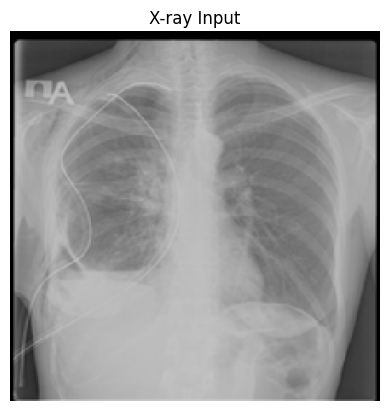

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
🚨 RESULT: TB DETECTED
Confidence: 0.46


In [ ]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

# Get file
img_path = list(uploaded.keys())[0]

# Load image
img = image.load_img(img_path, target_size=(224,224))

# Show image
plt.imshow(img)
plt.axis('off')
plt.title("X-ray Input")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# Instant decision
if pred > 0.4:
    print("🚨 RESULT: TB DETECTED")
    print(f"Confidence: {pred:.2f}")
else:
    print("✅ RESULT: NORMAL")
    print(f"Confidence: {1-pred:.2f}")

In [1]:
if pred > 0.6:
    print(f"🚨 TB DETECTED (High Confidence: {pred:.2f})")

elif pred > 0.4:
    print(f"⚠️ POSSIBLE TB (Medium Confidence: {pred:.2f})")

else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

NameError: name 'pred' is not defined

In [2]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import tensorflow as tf

# Load model
model = tf.keras.models.load_model("tb_detection_model.keras")

# Upload image
from google.colab import files
uploaded = files.upload()

# Get image path
img_path = list(uploaded.keys())[0]

# Load and show image
img = image.load_img(img_path, target_size=(224,224))
plt.imshow(img)
plt.axis('off')
plt.title("X-ray Input")
plt.show()

# Preprocess
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
pred = model.predict(img_array)[0][0]

# Decision system
if pred > 0.6:
    print(f"🚨 TB DETECTED (High Confidence: {pred:.2f})")

elif pred > 0.4:
    print(f"⚠️ POSSIBLE TB (Medium Confidence: {pred:.2f})")

else:
    print(f"✅ NORMAL (Confidence: {1-pred:.2f})")

ValueError: File not found: filepath=tb_detection_model.keras. Please ensure the file is an accessible `.keras` zip file.

In [3]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30
)

NameError: name 'model' is not defined

In [5]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

In [6]:
IMG_SIZE = 224
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "TB_Chest_Radiography_Database",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="training",
    seed=123
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "TB_Chest_Radiography_Database",
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    validation_split=0.2,
    subset="validation",
    seed=123
)

FileNotFoundError: [Errno 2] No such file or directory: 'TB_Chest_Radiography_Database'

In [8]:
!ls

'archive (3).zip'   sample_data


In [10]:
base_model.trainable = True

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

NameError: name 'base_model' is not defined

In [ ]:
import zipfile

with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('dataset')

FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

In [ ]:
---------------------------------------------------------------------------
FileNotFoundError                         Traceback (most recent call last)
/tmp/ipykernel_2376/3265464989.py in <cell line: 0>()
      1 import zipfile
      2
----> 3 with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
      4     zip_ref.extractall('dataset')

/usr/lib/python3.12/zipfile/__init__.py in __init__(self, file, mode, compression, allowZip64, compresslevel, strict_timestamps, metadata_encoding)
   1350             while True:
   1351                 try:
-> 1352                     self.fp = io.open(file, filemode)
   1353                 except OSError:
   1354                     if filemode in modeDict:

FileNotFoundError: [Errno 2] No such file or directory: 'archive.zip'

SyntaxError: invalid decimal literal (2185474235.py, line 3)

In [ ]:
import os
os.listdir('/kaggle/input')

In [ ]:
os.listdir('/kaggle/input/tuberculosis-chest-xray')

In [ ]:
import os
os.listdir('TB_Chest_Radiography_Database')

In [ ]:
import os
os.listdir()

In [ ]:
!ls -lh

In [ ]:
!ls

archive.zip  sample_data


In [ ]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [ ]:
os.listdir("dataset")

In [ ]:
import os
os.listdir("dataset/TB_Chest_Radiography_Database")

In [ ]:
import tensorflow as tf

dataset_path = "dataset/TB_Chest_Radiography_Database"

data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="binary",
    class_names=["Normal","Tuberculosis"],
    image_size=(224,224),
    batch_size=32
)

In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Rescaling(1./255),

    layers.Conv2D(32,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,3,activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128,activation='relu'),
    layers.Dense(1,activation='sigmoid')
])

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
model.fit(data, epochs=10)

NameError: name 'data' is not defined

In [ ]:
model.fit(data, epochs=10)

NameError: name 'data' is not defined

In [ ]:
model.fit(data, epochs=10)

NameError: name 'data' is not defined

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

NameError: name 'val_data' is not defined

In [ ]:
import tensorflow as tf

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/TB_Chest_Radiography_Database",
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    class_names=["Normal","Tuberculosis"]
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    "dataset/TB_Chest_Radiography_Database",
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224,224),
    batch_size=32,
    class_names=["Normal","Tuberculosis"]
)

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

In [ ]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

In [ ]:
model.fit(data, epochs=10)

In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

y_true = np.concatenate([y for x, y in val_data], axis=0)
y_pred = model.predict(val_data)
y_pred = (y_pred > 0.5)

cm = confusion_matrix(y_true, y_pred)

print(cm)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix for TB Detection")

plt.show()

In [ ]:
plt.plot(history.history['accuracy'])
plt.title("Model Accuracy")
plt.ylabel("Accuracy")
plt.xlabel("Epoch")
plt.show()

In [ ]:
model.save("tb_detection_model.h5")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("test_xray.jpg", target_size=(224,224))
img_array = image.img_to_array(img)/255
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
!ls

In [ ]:
!ls

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("test_xray.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
!ls

'archive (3).zip'   sample_data


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("test_xray.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
!ls

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("test_xray.jpg.png", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("normal_xray.jpg.png", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0] > 0.5:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
if prediction[0] > 0.5:

SyntaxError: incomplete input (3208637015.py, line 1)

In [ ]:
if prediction[0] > 0.7:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.7:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1️⃣ Load trained model
model = tf.keras.models.load_model("tb_detection_model.h5")

# 2️⃣ Load the X-ray image
img_path = "normal_xray.jpg"
img = image.load_img(img_path, target_size=(224,224))

# 3️⃣ Show the image
plt.imshow(img)
plt.axis("off")
plt.title("Input Chest X-ray")
plt.show()

# 4️⃣ Convert image to array
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 5️⃣ Predict
prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

# 6️⃣ TB or Normal
if prediction > 0.7:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray (No TB)")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'tb_detection_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

model = tf.keras.models.load_model("tb_detection_model.h5")

img = image.load_img("normal_xray.jpg", target_size=(224,224))

plt.imshow(img)
plt.axis("off")
plt.show()

img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.7:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

In [ ]:
!ls

In [ ]:
img = image.load_img("normal_xray.jpg.png", target_size=(224,224))

In [ ]:
!ls


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("tb_detection_model.h5")

# Load the X-ray image
img_path = "normal_xray.jpg.png"   # Exact file name
img = image.load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.title("Input Chest X-ray")
plt.show()

# Preprocess image
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)[0][0]
print("Prediction Score:", prediction)

# Decide TB or Normal
if prediction > 0.7:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray (No TB)")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("tb_detection_model.h5")

# Load the X-ray image
img_path = "Normal_941.jpg.png"   # Exact file name
img = image.load_img(img_path, target_size=(224,224))

# Display image
plt.imshow(img)
plt.axis("off")
plt.title("Input Chest X-ray")
plt.show()

# Preprocess image
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

# Make prediction
prediction = model.predict(img_array)[0][0]
print("Prediction Score:", prediction)

# Decide TB or Normal
if prediction > 0.7:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray (No TB)")

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.2
)

In [ ]:
if prediction > 0.7:

In [ ]:
if prediction > 0.7:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray (No TB)")

In [ ]:
prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.7:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray (No TB)")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# 1. Load the trained model
model = tf.keras.models.load_model("tb_detection_model.h5")

# 2. Load the X-ray image (use the exact file name you saw in !ls)
img_path = "Normal_xray999.jpg.png"
img = image.load_img(img_path, target_size=(224,224))

# 3. Show the image
plt.imshow(img)
plt.axis("off")
plt.title("Input Chest X-ray")
plt.show()

# 4. Convert image to array and normalize
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# 5. Predict
prediction = model.predict(img_array)

score = prediction[0][0]
print("Prediction Score:", score)

# 6. Decide TB or Normal
if score >= 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("tb_detection_model.h5")

# Load the X-ray image
img_path = "Normal_xray999.jpg"
img = image.load_img(img_path, target_size=(224,224))

# Show image
plt.imshow(img)
plt.axis("off")
plt.title("Input X-ray")
plt.show()

# Preprocess image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

# Result
if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'tb_detection_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

# Load trained model
model = tf.keras.models.load_model("tb_detection_model.h5")

# Load the X-ray image
img_path = "crop.jpg"
img = image.load_img(img_path, target_size=(224,224))

# Show image
plt.imshow(img)
plt.axis("off")
plt.title("Input X-ray")
plt.show()

# Preprocess image
img_array = image.img_to_array(img)
img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Predict
prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

# Result
if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'tb_detection_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("crop.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

FileNotFoundError: [Errno 2] No such file or directory: 'crop.jpg'

In [ ]:
!ls

archive.zip  sample_data


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("crop.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("crop pic.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Normal Chest X-ray")

In [ ]:
print(train_data.class_indices)

In [ ]:
if prediction > 0.5:
    print("Tuberculosis Detected")
else:
    print("Normal Chest X-ray")


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("crop pic.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Tuberculosis Not Detected")

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("normal_person.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Tuberculosis Not Detected")

In [ ]:
!ls

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("normal_person.jpg", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Tuberculosis Not Detected")

FileNotFoundError: [Errno 2] No such file or directory: 'normal_person.jpg'

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

img = image.load_img("normal_person.jpg.png", target_size=(224,224))

img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)[0][0]

print("Prediction Score:", prediction)

if prediction > 0.5:
    print("🦠 Tuberculosis Detected")
else:
    print("✅ Tuberculosis Not Detected")

FileNotFoundError: [Errno 2] No such file or directory: 'normal_person.jpg.png'

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
model.fit(
    train_data,
    validation_data=val_data,
    epochs=15
)

NameError: name 'train_data' is not defined

# New section